In [1]:
import pickle
import numpy as np
import librosa
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.optim import Adam

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
def extract_feature(data, sr, mfcc, chroma, mel):
    if chroma:                          
        stft = np.abs(librosa.stft(data))  
    result = np.array([])
    if mfcc:                          
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))
    if chroma:                          
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T,axis=0)
        result = np.hstack((result, chroma))
        
    if mel:           
        mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T,axis=0)
        result = np.hstack((result, mel))
        
    return result 

In [4]:
with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/Audio/subject_04_aud.pkl", "rb") as f:
    data_aud = pickle.load(f)

with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/EEG/subject_04_eeg.pkl", "rb") as f:
    data_eeg = pickle.load(f)


In [5]:
# Unpack data into training and testing features and labels
X_train_aud, y_train_aud, X_test_aud, y_test_aud = data_aud
X_train_eeg, y_train_eeg, X_test_eeg, y_test_eeg = data_eeg

In [6]:
X_train_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_train_aud])
X_test_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_test_aud])

/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
X_train_aud = torch.tensor(X_train_aud).unsqueeze(1).float()
y_train_aud = torch.tensor(y_train_aud)
X_test_aud = torch.tensor(X_test_aud).unsqueeze(1).float()
y_test_aud = torch.tensor(y_test_aud)

In [8]:
X_train_eeg = torch.tensor(X_train_eeg).unsqueeze(1).float()
X_test_eeg = torch.tensor(X_test_eeg).unsqueeze(1).float()

In [9]:
emotions = ["Neutral", "Sadness", "Anger", "Happiness", "Calmness"]

## Define Data Loader

In [10]:
class PairedModalDataset(Dataset):
    def __init__(self, X_eeg, X_audio, y):
        assert len(X_eeg) == len(X_audio) == len(y)
        self.X_eeg = torch.tensor(X_eeg, dtype=torch.float32)
        self.X_audio = torch.tensor(X_audio, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_eeg[idx], self.X_audio[idx], self.y[idx]

In [11]:
batch_size = 32
# Create a validation split from the training set
idx = np.arange(len(y_train_aud))
train_split_idx, val_split_idx = train_test_split(
    idx,
    test_size=0.1,
    random_state=42,
    stratify=np.array(y_train_aud)
)

# Keep originals, then slice
X_train_eeg_all = X_train_eeg
X_train_aud_all = X_train_aud
y_train_all = np.array(y_train_aud)

X_train_eeg = X_train_eeg_all[train_split_idx]
X_train_audio = X_train_aud_all[train_split_idx]
y_train = y_train_all[train_split_idx]

X_val_eeg = X_train_eeg_all[val_split_idx]
X_val_audio = X_train_aud_all[val_split_idx]
y_val = y_train_all[val_split_idx]

train_ds = PairedModalDataset(X_train_eeg, X_train_audio, y_train)  # audio and eeg Y are the same
val_ds = PairedModalDataset(X_val_eeg, X_val_audio, y_val)
test_ds  = PairedModalDataset(X_test_eeg,  X_test_aud,  y_test_aud)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


/tmp/ipykernel_2663001/2166164010.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  stratify=np.array(y_train_aud)
/tmp/ipykernel_2663001/2166164010.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train_all = np.array(y_train_aud)
/tmp/ipykernel_2663001/1108307568.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  

In [12]:
len(train_ds)

252

## Models

EEGNet + AudioSCNN backbones feed CoGCN (one view per modality).


In [13]:
class FusionLateHead(nn.Module):
    def __init__(self, eeg_model, audio_model, num_classes, hidden=256, p_drop=0.2):
        super().__init__()
        self.eeg = eeg_model
        self.audio = audio_model

        # Freeze experts
        for p in self.eeg.parameters():   p.requires_grad = False
        for p in self.audio.parameters(): p.requires_grad = False
        self.eeg.eval()
        self.audio.eval()

        in_dim = self.eeg.dense.in_features + self.audio.classifier.in_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x_eeg, x_audio):
        logits_eeg, feat_eeg = self.eeg(x_eeg, return_features=True)
        logits_audio, feat_audio = self.audio(x_audio, return_features=True)
        fused_in = torch.cat([feat_eeg, feat_audio], dim=1)
        out = self.head(fused_in)                                  # [B, C]
        return out, logits_eeg, logits_audio


In [14]:
from models import EEGNet, AudioSCNN, CoGCN
from util import construct_graph, sparse_mx_to_torch_sparse_tensor

n_class = len(emotions)

eeg_backbone = EEGNet(
    nb_classes=n_class,
    Chans=30,
    Samples=500,
    dropoutRate=0.5,
    kernLength=300,
    F1=8,
    D=8,
    F2=64,
    norm_rate=0.25,
    dropoutType='Dropout',
).to(device)
optim_eeg = Adam(eeg_backbone.parameters(), lr=1e-3)
criterion_eeg = nn.CrossEntropyLoss()


aud_backbone = AudioSCNN(n_classes=n_class).to(device)
optim_aud = torch.optim.Adam(aud_backbone.parameters(), lr=1e-3)
criterion_aud = nn.CrossEntropyLoss()


## Train Backbone Models Separately

In [15]:
def train_audio(model, optim, criterion, train_loader, val_loader, test_loader, epochs=100,
          l1_lambda=1e-5, l2_lambda=1e-4, bias_l2=1e-4, activity_l2=1e-5, device="cpu"):
    def kernel_l1_l2(model):
        # match Keras: Conv2/3/4 + Dense (classifier)
        params = [model.conv2.weight, model.conv3.weight, model.conv4.weight, model.classifier.weight]
        l1 = sum(p.abs().sum() for p in params)
        l2 = sum((p ** 2).sum() for p in params)
        return l1, l2

    # using val set
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    best_acc = -1.0
    best_state = None
    best_epoch = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_epoch_loss = 0
        train_correct = 0
        train_total = 0
        for eeg, audio, labels in train_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            # categorical_crossentropy expects class indices
            if labels.ndim > 1:
                labels_idx = labels.argmax(dim=1).long()
            else:
                labels_idx = labels.long()

            optim.zero_grad()
            outputs = model(audio)
            loss = criterion(outputs, labels_idx)

            l1, l2 = kernel_l1_l2(model)
            loss = loss + l1_lambda * l1 + l2_lambda * l2
            if model.classifier.bias is not None:
                loss = loss + bias_l2 * (model.classifier.bias ** 2).sum()
            loss = loss + activity_l2 * (outputs ** 2).sum()

            loss.backward()
            optim.step()

            train_epoch_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels_idx).sum().item()
            train_total += labels_idx.numel()

        train_epoch_loss = train_epoch_loss / len(train_loader)
        train_epoch_acc = train_correct / train_total if train_total else 0.0

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_acc)

        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for eeg, audio, labels in val_loader:
                eeg = eeg.to(dtype=torch.float32, device=device)
                audio = audio.to(dtype=torch.float32, device=device)
                labels = labels.to(device=device)

                if labels.ndim > 1:
                    labels_idx = labels.argmax(dim=1).long()
                else:
                    labels_idx = labels.long()

                outputs = model(audio)

                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels_idx).sum().item()
                val_total += labels_idx.numel()

        val_epoch_acc = val_correct / val_total if val_total else 0.0
        val_accuracies.append(val_epoch_acc)

        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1} Train loss = {train_epoch_loss:.3f} Train accuracy = {train_epoch_acc * 100 :.2f}% Val accuracy = {val_epoch_acc * 100 :.2f}%")

    print(f"Best epoch: {best_epoch}, Best Val accuracy: {best_acc}")
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final eval on test set for best model
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for eeg, audio, labels in test_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            if labels.ndim > 1:
                labels_idx = labels.argmax(dim=1).long()
            else:
                labels_idx = labels.long()

            outputs = model(audio)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_idx.cpu().numpy())

    best_test_acc = accuracy_score(all_labels, all_preds)
    best_test_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Best model Test Accuracy = {best_test_acc * 100:.2f}%")
    print(f"Best model Test F1 = {best_test_f1:.2f}")

    return model, train_losses, train_accuracies, val_accuracies


In [16]:
def train_eeg(model, optimizer, criterion, train_loader, val_loader, test_loader, epochs=100, device="cpu"):
    # using test set as validation here
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    best_acc = -1.0
    best_state = None
    best_epoch = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_epoch_loss = 0
        train_correct = 0
        train_total = 0
        for eeg, audio, labels in train_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(eeg)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.numel()


        train_epoch_loss = train_epoch_loss / len(train_loader)
        train_epoch_acc = train_correct / train_total if train_total else 0.

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_acc)

        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for eeg, audio, labels in val_loader:
                eeg = eeg.to(dtype=torch.float32, device=device)
                audio = audio.to(dtype=torch.float32, device=device)
                labels = labels.to(device=device)

                outputs = model(eeg)

                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_epoch_acc = val_correct / val_total if val_total else 0.0
        val_accuracies.append(val_epoch_acc)

        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1} Train loss = {train_epoch_loss:.3f} Train accuracy = {train_epoch_acc * 100 :.2f}% Val accuracy = {val_epoch_acc * 100 :.2f}%")

    print(f"Best epoch: {best_epoch}, Best Val accuracy: {best_acc}")
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final eval on test set for best model
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for eeg, audio, labels in test_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            if labels.ndim > 1:
                labels_idx = labels.argmax(dim=1).long()
            else:
                labels_idx = labels.long()

            outputs = model(eeg)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_idx.cpu().numpy())

    best_test_acc = accuracy_score(all_labels, all_preds)
    best_test_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Best model Test Accuracy = {best_test_acc * 100:.2f}%")
    print(f"Best model Test F1 = {best_test_f1:.2f}")

    return model, train_losses, train_accuracies, val_accuracies

In [17]:
def train_fusion(model, optimizer, criterion, train_loader, val_loader, test_loader, epochs=100, device="cpu"):
    # using test set as validation here
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    best_acc = -1.0
    best_state = None
    best_epoch = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_epoch_loss = 0
        train_correct = 0
        train_total = 0
        for eeg, audio, labels in train_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            outputs, _, _ = model(eeg, audio)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.numel()


        train_epoch_loss = train_epoch_loss / len(train_loader)
        train_epoch_acc = train_correct / train_total if train_total else 0.

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_acc)

        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for eeg, audio, labels in val_loader:
                eeg = eeg.to(dtype=torch.float32, device=device)
                audio = audio.to(dtype=torch.float32, device=device)
                labels = labels.to(device=device)

                outputs, _, _ = model(eeg, audio)

                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_epoch_acc = val_correct / val_total if val_total else 0.0
        val_accuracies.append(val_epoch_acc)

        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1} Train loss = {train_epoch_loss:.3f} Train accuracy = {train_epoch_acc * 100 :.2f}% Val accuracy = {val_epoch_acc * 100 :.2f}%")

    # print(f"Best epoch: {best_epoch}, Best Val accuracy: {best_acc}")
    # if best_state is not None:
    #     model.load_state_dict(best_state)

    # Final eval on test set for best model
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for eeg, audio, labels in test_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            if labels.ndim > 1:
                labels_idx = labels.argmax(dim=1).long()
            else:
                labels_idx = labels.long()

            outputs, _, _ = model(eeg, audio)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_idx.cpu().numpy())

    best_test_acc = accuracy_score(all_labels, all_preds)
    best_test_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Best model Test Accuracy = {best_test_acc * 100:.2f}%")
    print(f"Best model Test F1 = {best_test_f1:.2f}")

    return model, train_losses, train_accuracies, val_accuracies

In [18]:
print("Training AudioSCNN model")
aud_backbone, train_losses_aud, train_accs_aud, val_accs_aud = train_audio(aud_backbone, optim_aud, criterion_aud, train_loader, val_loader, test_loader, epochs=100, device=device)

Training AudioSCNN model
Epoch 1 Train loss = 2.393 Train accuracy = 23.41% Val accuracy = 21.43%
Epoch 2 Train loss = 1.726 Train accuracy = 26.19% Val accuracy = 17.86%
Epoch 3 Train loss = 1.701 Train accuracy = 23.02% Val accuracy = 28.57%
Epoch 4 Train loss = 1.430 Train accuracy = 32.54% Val accuracy = 39.29%
Epoch 5 Train loss = 1.233 Train accuracy = 45.24% Val accuracy = 50.00%
Epoch 6 Train loss = 1.205 Train accuracy = 45.24% Val accuracy = 53.57%
Epoch 7 Train loss = 1.136 Train accuracy = 52.38% Val accuracy = 53.57%
Epoch 8 Train loss = 1.079 Train accuracy = 54.76% Val accuracy = 46.43%
Epoch 9 Train loss = 1.028 Train accuracy = 56.75% Val accuracy = 57.14%
Epoch 10 Train loss = 0.939 Train accuracy = 64.29% Val accuracy = 67.86%
Epoch 11 Train loss = 0.835 Train accuracy = 71.43% Val accuracy = 78.57%
Epoch 12 Train loss = 0.774 Train accuracy = 73.41% Val accuracy = 71.43%
Epoch 13 Train loss = 0.761 Train accuracy = 72.62% Val accuracy = 71.43%
Epoch 14 Train loss = 

In [19]:
PATH = "/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth"
torch.save(aud_backbone.state_dict(), PATH)

In [20]:
print("Training EEGNet model")
eeg_backbone, train_losses_eeg, train_accs_eeg, val_accs_eeg = train_eeg(eeg_backbone, optim_eeg, criterion_eeg, train_loader, val_loader, test_loader, epochs=100, device=device)

Training EEGNet model
Epoch 1 Train loss = 1.596 Train accuracy = 26.59% Val accuracy = 21.43%
Epoch 2 Train loss = 1.503 Train accuracy = 42.86% Val accuracy = 28.57%
Epoch 3 Train loss = 1.405 Train accuracy = 45.63% Val accuracy = 21.43%
Epoch 4 Train loss = 1.373 Train accuracy = 51.98% Val accuracy = 17.86%


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/venv/lib/python3.12/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Epoch 5 Train loss = 1.341 Train accuracy = 53.57% Val accuracy = 17.86%
Epoch 6 Train loss = 1.308 Train accuracy = 55.56% Val accuracy = 14.29%
Epoch 7 Train loss = 1.281 Train accuracy = 57.54% Val accuracy = 17.86%
Epoch 8 Train loss = 1.260 Train accuracy = 55.95% Val accuracy = 14.29%
Epoch 9 Train loss = 1.210 Train accuracy = 57.94% Val accuracy = 25.00%
Epoch 10 Train loss = 1.207 Train accuracy = 61.51% Val accuracy = 21.43%
Epoch 11 Train loss = 1.173 Train accuracy = 60.71% Val accuracy = 25.00%
Epoch 12 Train loss = 1.158 Train accuracy = 62.30% Val accuracy = 21.43%
Epoch 13 Train loss = 1.131 Train accuracy = 62.30% Val accuracy = 14.29%
Epoch 14 Train loss = 1.115 Train accuracy = 63.10% Val accuracy = 14.29%
Epoch 15 Train loss = 1.098 Train accuracy = 61.51% Val accuracy = 14.29%
Epoch 16 Train loss = 1.068 Train accuracy = 65.87% Val accuracy = 21.43%
Epoch 17 Train loss = 1.062 Train accuracy = 67.46% Val accuracy = 28.57%
Epoch 18 Train loss = 1.031 Train accuracy 

In [21]:
PATH = "/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth"
torch.save(eeg_backbone.state_dict(), PATH)

In [22]:
eeg_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth", map_location=device))
aud_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth", map_location=device))

<All keys matched successfully>

In [23]:
fusion = FusionLateHead(eeg_backbone, aud_backbone, num_classes=n_class, hidden=256, p_drop=0.2).to(device)
optim_fusion = torch.optim.AdamW(fusion.head.parameters(), lr=5e-4, weight_decay=1e-4)
criterion_fusion = nn.CrossEntropyLoss()

In [24]:
print("Training Fusion model")
fusion, train_losses_fusion, train_accs_fusion, val_accs_fusion = train_fusion(fusion, optim_fusion, criterion_fusion, train_loader, val_loader, test_loader, epochs=100, device=device)

Training Fusion model
Epoch 1 Train loss = 0.825 Train accuracy = 78.57% Val accuracy = 85.71%
Epoch 2 Train loss = 0.136 Train accuracy = 98.41% Val accuracy = 85.71%
Epoch 3 Train loss = 0.038 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 4 Train loss = 0.024 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 5 Train loss = 0.027 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 6 Train loss = 0.011 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 7 Train loss = 0.008 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 8 Train loss = 0.012 Train accuracy = 99.60% Val accuracy = 89.29%
Epoch 9 Train loss = 0.014 Train accuracy = 99.60% Val accuracy = 89.29%
Epoch 10 Train loss = 0.007 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 11 Train loss = 0.007 Train accuracy = 100.00% Val accuracy = 89.29%
Epoch 12 Train loss = 0.015 Train accuracy = 99.60% Val accuracy = 89.29%
Epoch 13 Train loss = 0.017 Train accuracy = 99.21% Val accuracy = 89.29%
Epoch 14 Train los

Test acc: 0.8667 | F1-macro: 0.8677 | F1-weighted: 0.8677


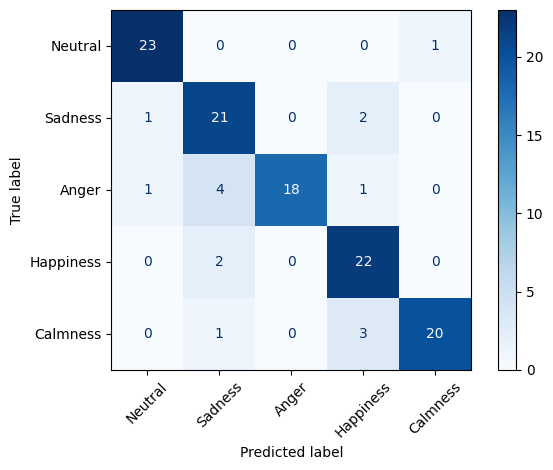

In [25]:
# Evaluate on test set
fusion.eval()

preds, _, _ = fusion(X_test_eeg.to(device), X_test_aud.to(device))
preds = preds.argmax(dim=1).cpu()

acc = accuracy_score(y_test_aud, preds)
f1_macro = f1_score(y_test_aud, preds, average="macro")
f1_weighted = f1_score(y_test_aud, preds, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_test_aud, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()


## Train (Backbones + CoGCN)

We build graphs from current backbone features (detached) and train end-to-end.


### Build indices & graphs (frozen phase)


In [26]:
# Build full tensors and indices (train/val/test are contiguous blocks)
X_eeg_all = torch.cat([X_train_eeg, X_val_eeg, X_test_eeg], dim=0).to(device)
X_aud_all = torch.cat([X_train_audio, X_val_audio, X_test_aud], dim=0).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=device)
y_test_t = y_test_aud.to(device).long() if torch.is_tensor(y_test_aud) else torch.tensor(y_test_aud, dtype=torch.long, device=device)
y_all = torch.cat([y_train_t, y_val_t, y_test_t], dim=0)

n_train = len(y_train)
n_val = len(y_val)
n_test = len(y_test_aud)
train_idx = torch.arange(0, n_train, device=device)
val_idx = torch.arange(n_train, n_train + n_val, device=device)
test_idx = torch.arange(n_train + n_val, n_train + n_val + n_test, device=device)

# Hyperparams
lr = 1e-3
weight_decay = 5e-4
k = 10
epochs_frozen = 1000

low_lr = 1e-5
epochs_finetune = 50
rebuild_epochs = {1, max(2, epochs_finetune // 2)}  # rebuild once or twice

# CoGCN params
lr_alpha = 0.01
dropout = 0.3


### Freeze backbones and build graphs once


In [27]:
eeg_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth", map_location=device))
aud_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth", map_location=device))

<All keys matched successfully>

In [28]:
def build_graphs(feat_eeg, feat_aud, y_np, k):
    Adj0 = construct_graph(feat_eeg, targets=y_np, k=k, metric="euclidean")
    Adj1 = construct_graph(feat_aud, targets=y_np, k=k, metric="euclidean")
    return [
        sparse_mx_to_torch_sparse_tensor(Adj0).to(device),
        sparse_mx_to_torch_sparse_tensor(Adj1).to(device),
    ]

def set_requires_grad(model, flag):
    for p in model.parameters():
        p.requires_grad = flag

# Freeze backbones
set_requires_grad(eeg_backbone, False)
set_requires_grad(aud_backbone, False)
eeg_backbone.eval()
aud_backbone.eval()

with torch.no_grad():
    logits_eeg, feat_eeg = eeg_backbone(X_eeg_all, return_features=True)
    logits_aud, feat_aud = aud_backbone(X_aud_all, return_features=True)

feat_eeg = feat_eeg.detach().cpu().numpy().astype(np.float32)
feat_aud = feat_aud.detach().cpu().numpy().astype(np.float32)

adjs = build_graphs(feat_eeg, feat_aud, y_all.detach().cpu().numpy(), k)


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/code/co-gcn/util.py:30: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(indices, values, shape)


### Init CoGCN per view + optimizers


In [29]:
n_view = 2
cogcn_nets = [
    CoGCN(nfeat=feat_eeg.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
    CoGCN(nfeat=feat_aud.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
]

optimizers = [
    torch.optim.Adam(cogcn_nets[0].parameters(), lr=lr, weight_decay=weight_decay),
    torch.optim.Adam(cogcn_nets[1].parameters(), lr=lr, weight_decay=weight_decay),
]


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/code/co-gcn/models.py:22: UserWarning: torch.sparse.SparseTensor(shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:685.)
  self.adj = torch.sparse.FloatTensor(self.n, self.n)


### Frozen phase training (per-view loss)


In [30]:
best_val = 0.0
best_epoch = 0
best_state = None

# Cache feature tensors once (backbones are frozen)
feat_eeg_t = torch.tensor(feat_eeg, device=device)
feat_aud_t = torch.tensor(feat_aud, device=device)

for epoch in range(1, epochs_frozen + 1):
    # train each view separately
    for v in range(n_view):
        cogcn_nets[v].train()
        optimizers[v].zero_grad()
        out_v = cogcn_nets[v](feat_eeg_t if v == 0 else feat_aud_t)
        loss = F.nll_loss(out_v[train_idx], y_all[train_idx])
        loss.backward()
        optimizers[v].step()
        cogcn_nets[v].gc1.update_alpha()
        cogcn_nets[v].gc2.update_alpha()

    # ensemble eval (train/val only)
    for v in range(n_view):
        cogcn_nets[v].eval()
    with torch.no_grad():
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    val_acc = (pred[val_idx] == y_all[val_idx]).float().mean().item()

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        best_state = {
            'cogcn0': copy.deepcopy(cogcn_nets[0].state_dict()),
            'cogcn1': copy.deepcopy(cogcn_nets[1].state_dict()),
        }

    if epoch % 20 == 0 or epoch == 1:
        print(f"[Frozen] Epoch {epoch:03d} | acc train/val: {train_acc:.3f}/{val_acc:.3f}")

print('Best val:', best_val, 'Best epoch:', best_epoch)

# Load best checkpoint from memory
if best_state is not None:
    cogcn_nets[0].load_state_dict(best_state['cogcn0'])
    cogcn_nets[1].load_state_dict(best_state['cogcn1'])


[Frozen] Epoch 001 | acc train/val: 0.766/0.679
[Frozen] Epoch 020 | acc train/val: 1.000/0.893
[Frozen] Epoch 040 | acc train/val: 1.000/0.929
[Frozen] Epoch 060 | acc train/val: 1.000/0.929
[Frozen] Epoch 080 | acc train/val: 1.000/0.929
[Frozen] Epoch 100 | acc train/val: 1.000/0.929
[Frozen] Epoch 120 | acc train/val: 1.000/0.929
[Frozen] Epoch 140 | acc train/val: 1.000/0.929
[Frozen] Epoch 160 | acc train/val: 1.000/0.929
[Frozen] Epoch 180 | acc train/val: 1.000/0.929
[Frozen] Epoch 200 | acc train/val: 1.000/0.929
[Frozen] Epoch 220 | acc train/val: 1.000/0.929
[Frozen] Epoch 240 | acc train/val: 1.000/0.929
[Frozen] Epoch 260 | acc train/val: 1.000/0.929
[Frozen] Epoch 280 | acc train/val: 1.000/0.929
[Frozen] Epoch 300 | acc train/val: 1.000/0.929
[Frozen] Epoch 320 | acc train/val: 1.000/0.929
[Frozen] Epoch 340 | acc train/val: 1.000/0.929
[Frozen] Epoch 360 | acc train/val: 1.000/0.929
[Frozen] Epoch 380 | acc train/val: 1.000/0.929
[Frozen] Epoch 400 | acc train/val: 1.00

Test acc: 0.8667 | F1-macro: 0.8653 | F1-weighted: 0.8653


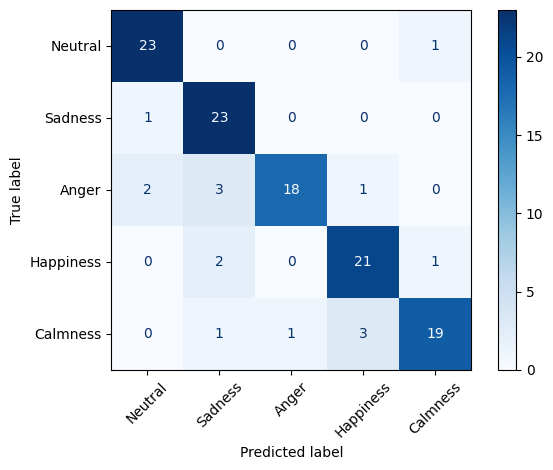

In [31]:
# Evaluate on test set
eeg_backbone.eval()
aud_backbone.eval()
for net in cogcn_nets:
    net.eval()

with torch.no_grad():
    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
    out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

y_true = y_all[test_idx].cpu().numpy()
y_pred = out_sum[test_idx].argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()


### Fine-tune (unfreeze backbones, low LR)


In [32]:
# Unfreeze backbones
set_requires_grad(eeg_backbone, True)
set_requires_grad(aud_backbone, True)

# Single optimizer over all params (backbones + CoGCN nets)
params = list(eeg_backbone.parameters()) + list(aud_backbone.parameters())
for net in cogcn_nets:
    params += list(net.parameters())
opt = torch.optim.Adam(params, lr=low_lr, weight_decay=weight_decay)

best_val = 0.0
best_epoch = 0
best_state = None
best_adjs = None

for epoch in range(1, epochs_finetune + 1):
    eeg_backbone.train()
    aud_backbone.train()
    for net in cogcn_nets:
        net.train()

    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)

    # Rebuild graphs once or twice using updated features
    if epoch % 10 == 0:
        adjs = build_graphs(
            feat_eeg_t.detach().cpu().numpy().astype(np.float32),
            feat_aud_t.detach().cpu().numpy().astype(np.float32),
            y_all.detach().cpu().numpy(),
            k,
        )
        for net in cogcn_nets:
            net.gc1.adjs = adjs
            net.gc2.adjs = adjs
            net.gc1._update_adj()
            net.gc2._update_adj()

    # Per-view losses, summed (graphs fixed between rebuilds)
    out_v0 = cogcn_nets[0](feat_eeg_t)
    out_v1 = cogcn_nets[1](feat_aud_t)
    loss = F.nll_loss(out_v0[train_idx], y_all[train_idx]) + \
            F.nll_loss(out_v1[train_idx], y_all[train_idx])

    opt.zero_grad()
    loss.backward()
    opt.step()

    for net in cogcn_nets:
        net.gc1.update_alpha()
        net.gc2.update_alpha()

    # Ensemble eval (train/val only)
    eeg_backbone.eval()
    aud_backbone.eval()
    for net in cogcn_nets:
        net.eval()
    with torch.no_grad():
        _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
        _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    val_acc = (pred[val_idx] == y_all[val_idx]).float().mean().item()

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        best_state = {
            'eeg': copy.deepcopy(eeg_backbone.state_dict()),
            'aud': copy.deepcopy(aud_backbone.state_dict()),
            'cogcn0': copy.deepcopy(cogcn_nets[0].state_dict()),
            'cogcn1': copy.deepcopy(cogcn_nets[1].state_dict()),
        }
        best_adjs = adjs

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Finetune] Epoch {epoch:03d} | loss {loss.item():.4f} | acc train/val: {train_acc:.3f}/{val_acc:.3f}")

print('Best val:', best_val, 'Best epoch:', best_epoch)

# Load best checkpoint + corresponding graphs from memory
if best_state is not None:
    eeg_backbone.load_state_dict(best_state['eeg'])
    aud_backbone.load_state_dict(best_state['aud'])
    cogcn_nets[0].load_state_dict(best_state['cogcn0'])
    cogcn_nets[1].load_state_dict(best_state['cogcn1'])
    if best_adjs is not None:
        for net in cogcn_nets:
            net.gc1.adjs = best_adjs
            net.gc2.adjs = best_adjs
            net.gc1._update_adj()
            net.gc2._update_adj()


[Finetune] Epoch 001 | loss 0.8160 | acc train/val: 1.000/0.929
[Finetune] Epoch 010 | loss 0.8064 | acc train/val: 1.000/0.929
[Finetune] Epoch 020 | loss 0.7089 | acc train/val: 1.000/0.929
[Finetune] Epoch 030 | loss 0.9007 | acc train/val: 1.000/0.929
[Finetune] Epoch 040 | loss 0.8832 | acc train/val: 1.000/0.929
[Finetune] Epoch 050 | loss 0.6114 | acc train/val: 1.000/0.929
Best val: 0.9285714626312256 Best epoch: 1


### Test metrics (accuracy, F1, confusion matrix)


Test acc: 0.8667 | F1-macro: 0.8651 | F1-weighted: 0.8651


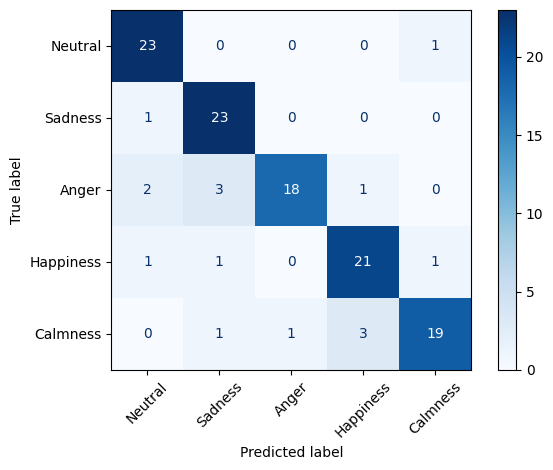

In [33]:
# Evaluate on test set
eeg_backbone.eval()
aud_backbone.eval()
for net in cogcn_nets:
    net.eval()

with torch.no_grad():
    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
    out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

y_true = y_all[test_idx].cpu().numpy()
y_pred = out_sum[test_idx].argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()
